In [6]:
import sklearn
print(sklearn.__version__)

1.8.0


In [7]:
import pandas as pd

df = pd.read_csv("rose_tulsi_watering_dataset_v4_with_status.csv")

print(df.shape)
df.head()

(1200, 13)


,Plant_Type,Temperature_C,Humidity_%,Soil_Moisture,Light_Intensity_lux,Plant_Height_cm,Plant_Age_days,Season,Weather,Planter_Type,Pot_Volume_Liters,Irrigation_Status,Water_Amount_ml
0,Rose,19.22,87.39,604,1745,23.3,101,Winter,Rainy,Clay Pot,10,1,63
1,Tulsi,21.96,74.25,678,634,77.5,111,Summer,Cloudy,Ceramic Pot,10,0,0
2,Rose,19.43,51.20,350,513,76.9,72,Summer,Sunny,Grow Bag,5,1,117
3,Rose,17.22,47.79,575,1938,23.6,147,Monsoon,Rainy,Plastic Pot,10,1,41
4,Rose,18.02,50.98,543,484,31.1,99,Summer,Cloudy,Plastic Pot,10,1,114


In [8]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Plant_Type           1200 non-null   str    
 1   Temperature_C        1200 non-null   float64
 2   Humidity_%           1200 non-null   float64
 3   Soil_Moisture        1200 non-null   int64  
 4   Light_Intensity_lux  1200 non-null   int64  
 5   Plant_Height_cm      1200 non-null   float64
 6   Plant_Age_days       1200 non-null   int64  
 7   Season               1200 non-null   str    
 8   Weather              1200 non-null   str    
 9   Planter_Type         1200 non-null   str    
 10  Pot_Volume_Liters    1200 non-null   int64  
 11  Irrigation_Status    1200 non-null   int64  
 12  Water_Amount_ml      1200 non-null   int64  
dtypes: float64(3), int64(6), str(4)
memory usage: 122.0 KB
None
       Temperature_C   Humidity_%  Soil_Moisture  Light_Intensity_lux  \
count    1200.00

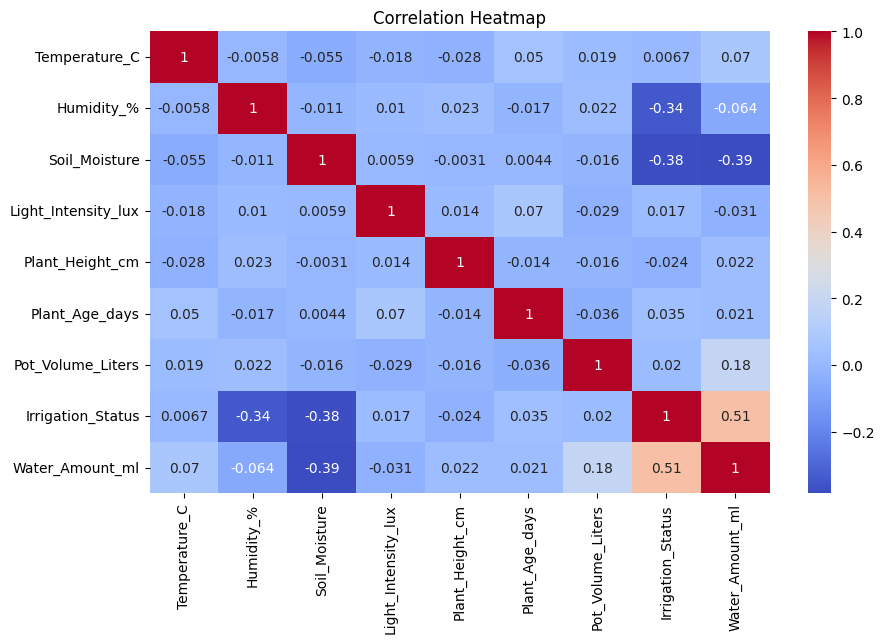

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [10]:
X = df.drop(["Water_Amount_ml", "Irrigation_Status", "Light_Intensity_lux", "Plant_Height_cm", "Weather","Planter_Type"], axis=1)
y = df["Water_Amount_ml"]
X.columns

Index(['Plant_Type', 'Temperature_C', 'Humidity_%', 'Soil_Moisture',
       'Plant_Age_days', 'Season', 'Pot_Volume_Liters'],
      dtype='str')

In [11]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))


Categorical: ['Plant_Type', 'Season']
Numerical: ['Temperature_C', 'Humidity_%', 'Soil_Moisture', 'Plant_Age_days', 'Pot_Volume_Liters']


C:\Users\Kedar\AppData\Local\Temp\ipykernel_20804\966894500.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
])


In [14]:
preprocessor_rf = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
], remainder="passthrough")


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("regressor", LinearRegression())
])


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])


In [17]:
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [18]:
import numpy as np

y_pred = rf_model.predict(X_test)

# Avoid unrealistic values
y_pred = np.clip(y_pred, 0, 650)


In [19]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 2.604041666666667
RMSE: 3.4106874612507863
R2  : 0.9907344157930512


In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())


Cross-Validation R2 Scores: [0.95955895 0.96269657 0.98804614 0.98178815 0.98945745]
Mean CV R2: 0.9763094511002869


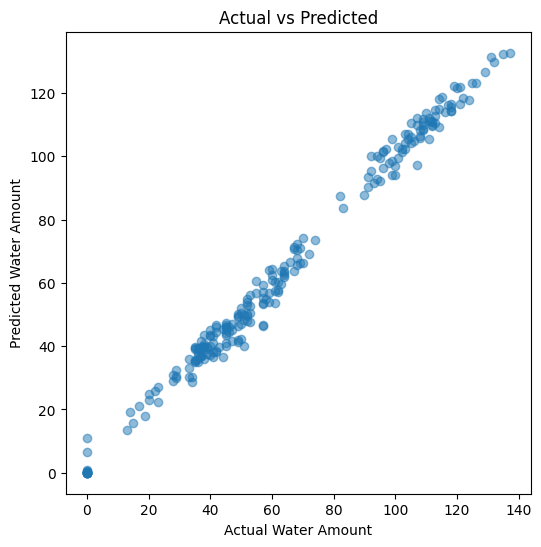

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Water Amount")
plt.ylabel("Predicted Water Amount")
plt.title("Actual vs Predicted")
plt.show()

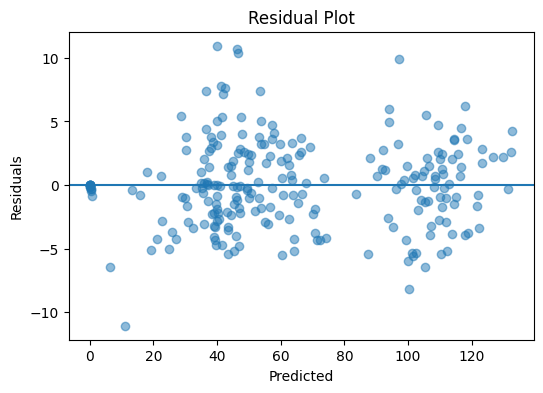

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [23]:
importances = rf_model.named_steps["regressor"].feature_importances_
features = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))


                        Feature  Importance
1            cat__Season_Summer    0.535329
5      remainder__Soil_Moisture    0.212434
4         remainder__Humidity_%    0.173355
7  remainder__Pot_Volume_Liters    0.034098
2            cat__Season_Winter    0.025213
0         cat__Plant_Type_Tulsi    0.012843
3      remainder__Temperature_C    0.004812
6     remainder__Plant_Age_days    0.001915


In [29]:
sample = pd.DataFrame([{
    "Plant_Type": "Rose",
    "Temperature_C": 30,
    "Humidity_%": 55,
    "Soil_Moisture": 400,
    "Plant_Age_days": 60,
    "Pot_Volume_Liters": 5,
    "Season": "Summer"
}])



In [30]:
prediction = rf_model.predict(sample)
print("Predicted Water (ml):", prediction[0])


Predicted Water (ml): 117.315


In [ ]:
y_pred_test = rf_model.predict(X_test)
y_pred_test[:10]


array([75.035, 73.14 , 67.515, 54.57 , 86.015, 52.695, 68.01 , 77.495,
       75.885, 74.38 ])

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_test
})

comparison.head(10)


,Actual,Predicted
0,109,75.035
1,119,73.140
2,13,67.515
3,37,54.570
4,124,86.015
5,94,52.695
6,22,68.010
7,42,77.495
8,61,75.885
9,118,74.380


In [ ]:
wet_case = pd.DataFrame([{
    "Plant_Type": "Tulsi",
    "Temperature_C": 24,
    "Humidity_%": 80,
    "Soil_Moisture": 750,
    "Plant_Age_days": 40,
    "Season": "Monsoon",
    "Weather": "Rainy",
    "Planter_Type": "Plastic Pot",
    "Pot_Volume_Liters": 5
}])

print(rf_model.predict(wet_case))


[0.]


In [ ]:
dry_case = pd.DataFrame([{
    "Plant_Type": "Rose",
    "Temperature_C": 38,
    "Humidity_%": 35,
    "Soil_Moisture": 250,
    "Plant_Age_days": 90,
    "Season": "Summer",
    "Weather": "Sunny",
    "Planter_Type": "Clay Pot",
    "Pot_Volume_Liters": 10
}])

print(rf_model.predict(dry_case))


[78.78]


In [ ]:
import pickle

with open("watering_model_rf_v1.pkl", "wb") as f:
    pickle.dump(rf_model, f)